# Global stout SU(3) downsampling: L24 → L12

The L12 and L24 ensembles are Wilson pure-gauge SU(3) configurations generated with QUDA heatbath plus overrelaxation. Each Monte Carlo step is 1 heatbath hit followed by 4 overrelaxation hits. Both ensembles start from a hot configuration, thermalize for 1000 steps, and then save a configuration every 100 steps (300 configurations each).

| ensemble | volume | β | lattice spacing |
| --- | --- | --- | --- |
| L24 | $24^4$ | 6.20 | $a = 0.07224\,\mathrm{fm}$ |
| L12 | $12^4$ | 5.80 | $a = 0.13732\,\mathrm{fm}$ |

Fine L24 configurations pass through a covariant polynomial smoother with longitudinal hooks and optional plaquette-conditioned coefficients, an SU(3) polar projection, and factor-two blocking. Here “stout” is the repository's name for this projected polynomial map.

The default run refines the previous hook-polynomial checkpoint with a fixed 60-configuration training subset and analytic-Jacobian trust-region least squares. The partition is 180/60/60 for train/validation/test. Only training configurations enter the fit; the default histograms show all 60 held-out test configurations. Set `RGFLOW_DOWNSAMPLE_RUN` to inspect another completed run and `SPLIT` below to inspect another saved split.


## Result of this refinement

The 40-evaluation budget reduces the fixed-subset training objective from 304.015 to 5.68530; the optimizer stops at the evaluation limit rather than declaring convergence.

On the complete 60-configuration held-out test split, all four mean shifts are within one target standard deviation. Rectangle and square widths satisfy the 20% criterion. Plaquette is too wide (std ratio 1.259) and Polyakov is too narrow (0.725), so **the complete distribution criterion is not satisfied**. The stricter requirement that all means lie within one combined standard error is also not satisfied. The plots and table below retain these limitations.


In [1]:
from pathlib import Path
import csv, json, os, sys
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

ROOT = next(path for path in (Path.cwd(), Path.cwd().parent) if (path / 'src' / 'rgflow').exists())
RUN = Path(os.environ.get('RGFLOW_DOWNSAMPLE_RUN', ROOT / 'artifacts' / '4dsu3' / 'downsample' / 'L24_beta6p20_to_L12_beta5p80_polynomial_local_ls_v2'))
SPLIT = 'test'
for filename in ('metrics.json', 'kernel.json', 'observable_distributions.npz'):
    if not (RUN / filename).exists():
        raise FileNotFoundError(f'{RUN / filename} not found; finish scripts/downsample/fit_polynomial.py first')
metrics = json.loads((RUN / 'metrics.json').read_text(encoding='utf-8'))
kernel = json.loads((RUN / 'kernel.json').read_text(encoding='utf-8'))
least_squares_fit = kernel['optimizer']['name'] == 'least_squares'
if least_squares_fit:
    fit_history = json.loads((RUN / 'fit_history.json').read_text(encoding='utf-8'))
else:
    with (RUN / 'history.csv').open(newline='', encoding='utf-8') as stream:
        rows = list(csv.DictReader(stream))
    history = {key: np.asarray([float(row[key]) for row in rows]) for key in rows[0]}
with np.load(RUN / 'observable_distributions.npz') as saved:
    reference = saved[f'reference_{SPLIT}'].copy()
    baseline = saved[f'baseline_{SPLIT}'].copy()
    downsampled = saved[f'trained_{SPLIT}'].copy()
names = tuple(metrics['observables'])
sys.path.insert(0, str(ROOT / 'scripts' / 'heatbath'))
from plot_settings import (
    BLUE, FIG_SIZE, FONT_SIZE, GREEN, LABEL_SIZE, LEGEND_SIZE, ORANGE, apply_plot_style, default_plot,
)
apply_plot_style()
plt.rcParams.update({
    'axes.labelsize': FONT_SIZE['fontsize'],
    'axes.titlesize': FONT_SIZE['fontsize'],
    'legend.fontsize': LEGEND_SIZE['fontsize'],
    'axes.formatter.use_mathtext': True,
})

def style_axis(axis):
    axis.tick_params(direction='in', top=True, right=True, **LABEL_SIZE)
    axis.grid(linestyle=':')

print(f'{RUN.name}: {SPLIT} split, {len(reference)} configurations')
print('optimizer:', {key: value for key, value in kernel['optimizer'].items() if key != 'fit_indices'})
for key in ('coefficients', 'hook_coefficients', 'local_coefficients'):
    print(f'{key}:', kernel['architecture'].get(key, []))


L24_beta6p20_to_L12_beta5p80_polynomial_local_ls_v2: test split, 60 configurations
optimizer: {'name': 'least_squares', 'max_nfev': 40, 'nfev': 40, 'njev': 34, 'success': False, 'message': 'The maximum number of function evaluations is exceeded.'}
coefficients: [0.19842116820508549, -0.023623959150709608, -0.002876974930039361, -6.659929755087942e-05]
hook_coefficients: [0.03923634321940892, 0.025011816411499237, 0.002998340020904962]
local_coefficients: [0.03779125485869483, -0.021583716689496504, 0.002722206164464504, -0.00022328007225943015]


## Training objective

The least-squares objective fits four means and four log variances on a fixed training subset. For independent fine and reference ensembles,

$$r_{\mathrm{mean},j}=\frac{\bar O_{f,j}-\bar O_{c,j}}{\sigma_{c,j}\sqrt{1/n_f+1/n_c}},\qquad
r_{\mathrm{var},j}=\frac{\log(s_{f,j}^2/s_{c,j}^2)}{\sqrt{2/(n_f-1)+2/(n_c-1)}},\qquad J=\sum_j(r_{\mathrm{mean},j}^2+r_{\mathrm{var},j}^2).$$

The plot includes trial evaluations, which can increase the objective, and the best value seen so far. The analytic Jacobian differentiates ensemble moments through the projection and observables. The final checkpoint is the optimizer's training solution; validation and test splits are evaluated afterwards. Legacy Adam runs show their saved train/validation history instead. Their covariance-weighted chi² is a different objective from $J$ and should not be compared numerically with it.


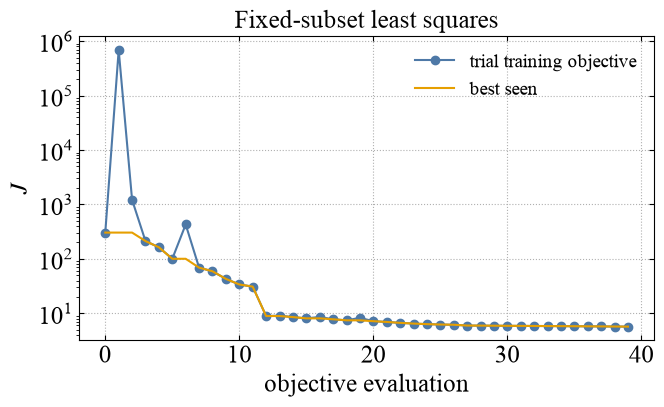

In [2]:
figure, axis = default_plot()
if least_squares_fit:
    evaluations = np.asarray([row['evaluation'] for row in fit_history])
    losses = np.asarray([row['loss'] for row in fit_history])
    axis.plot(evaluations, losses, 'o-', color=BLUE, label='trial training objective')
    axis.plot(evaluations, np.minimum.accumulate(losses), '-', color=ORANGE, label='best seen')
    axis.set_xlabel('objective evaluation')
    axis.set_ylabel(r'$J$')
    axis.set_title('Fixed-subset least squares')
else:
    axis.plot(history['epoch'], history['train_loss'], 'o-', color=BLUE, label='train')
    axis.plot(history['epoch'], history['validation_loss'], 'o-', color=ORANGE, label='validation')
    axis.set_xlabel('epoch')
    axis.set_ylabel(r'$\chi^2$')
    axis.set_title(r'Training $\chi^2$')
axis.set_yscale('log')
axis.legend(frameon=False)
figure.tight_layout()
plt.show()


## Held-out observable distributions

The native L12, fitted polynomial map, and naive two-link map are measured on the selected split. Each sample uses its own Freedman–Diaconis bins; the axes cover all three samples. The table below quantifies shifts and widths when the naive map is too far away to judge overlap visually.


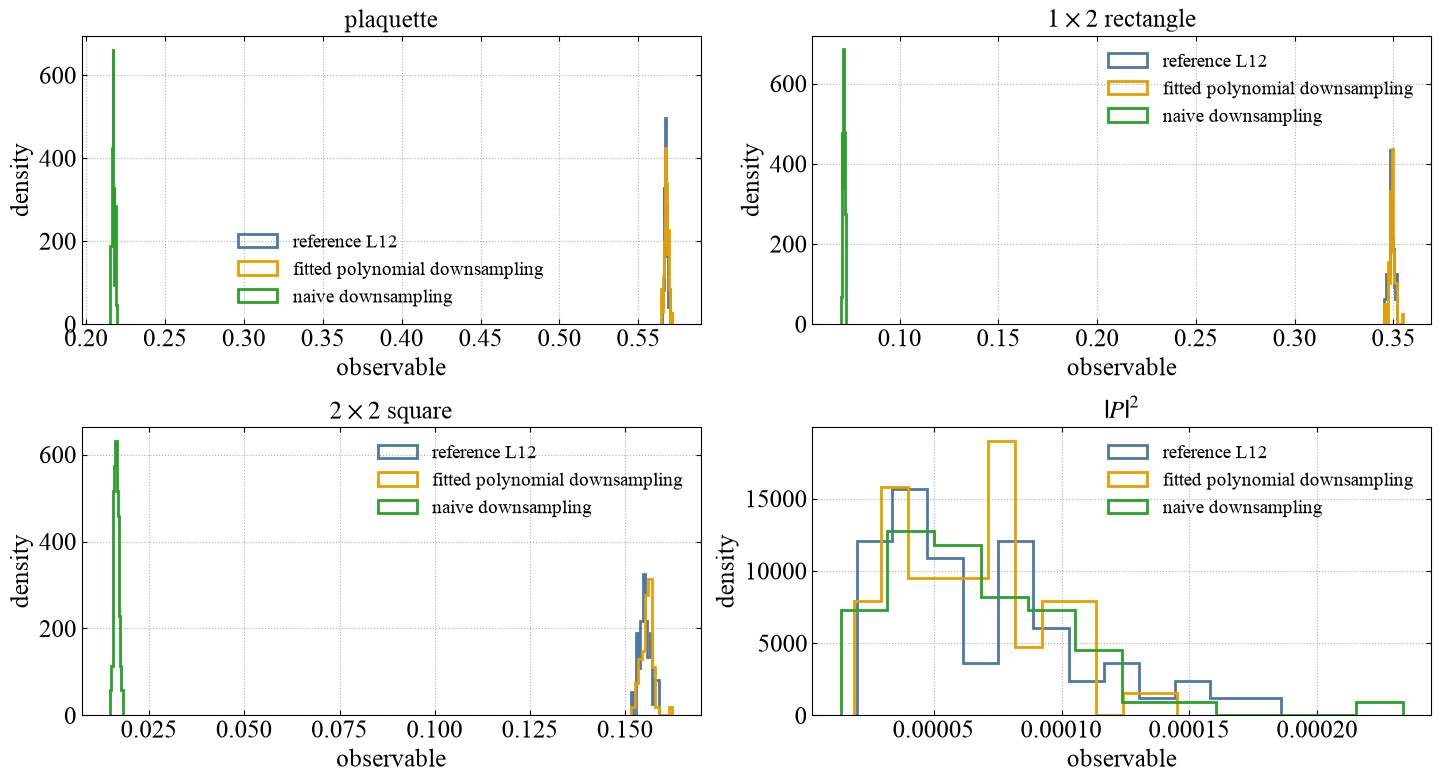

In [3]:
def sample_bins(values, minimum=12, maximum=40):
    values = np.asarray(values, dtype=float)
    lower, upper = float(values.min()), float(values.max())
    if upper <= lower:
        pad = 0.5 if upper == lower else 0.05 * max(abs(lower), 1.0)
        return np.linspace(lower - pad, upper + pad, minimum + 1)
    iqr = float(np.percentile(values, 75) - np.percentile(values, 25))
    width = 2.0 * iqr * len(values) ** (-1.0 / 3.0)
    count = minimum if width <= 0 else int(np.ceil((upper - lower) / width))
    count = int(np.clip(count, minimum, maximum))
    return np.linspace(lower, upper, count + 1)

labels = {
    'plaquette': 'plaquette',
    'rectangle_1x2': r'$1\times 2$ rectangle',
    'square_2x2': r'$2\times 2$ square',
    'polyakov_abs2': r'$|P|^2$',
}
series = (
    (reference, BLUE, 'reference L12'),
    (downsampled, ORANGE, 'fitted polynomial downsampling'),
    (baseline, GREEN, 'naive downsampling'),
)
figure, axes = plt.subplots(2, 2, figsize=(FIG_SIZE[0] * 2.15, FIG_SIZE[1] * 1.9))
for index, (axis, name) in enumerate(zip(axes.flat, names)):
    for sample, color, label in series:
        values = sample[:, index]
        axis.hist(values, bins=sample_bins(values), density=True, histtype='step', linewidth=2.0, color=color, label=label)
    style_axis(axis)
    axis.set_title(labels.get(name, name))
    axis.set_xlabel('observable')
    axis.set_ylabel('density')
    axis.legend(frameon=False)
figure.tight_layout()
plt.show()

## Reference and fitted map at the target scale

This view uses the native L12 mean and standard deviation to normalize each observable. Reference and fitted samples use shared bins, making their widths and overlap visible without the distant naive baseline expanding the horizontal range.


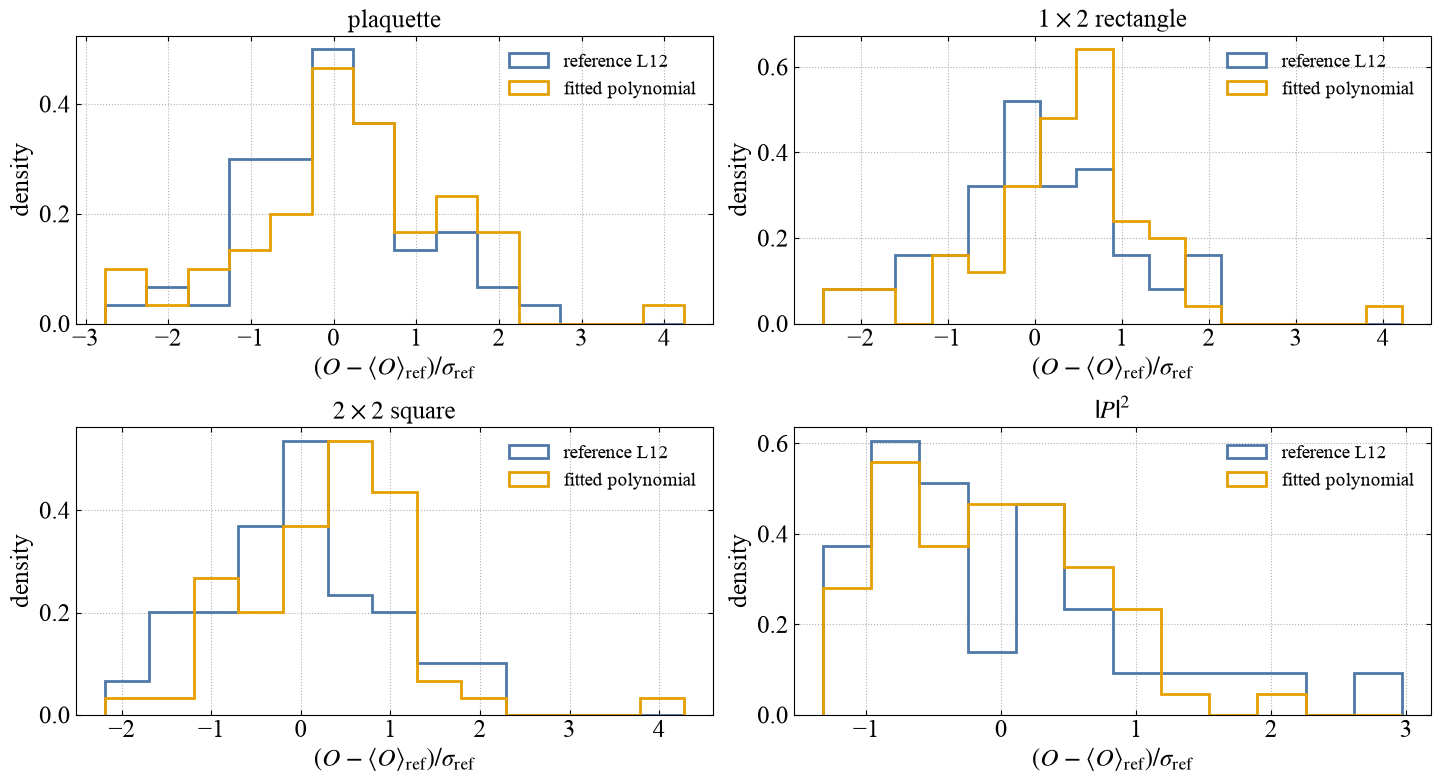

In [4]:
center = reference.mean(axis=0)
scale = reference.std(axis=0, ddof=1)
figure, axes = plt.subplots(2, 2, figsize=(FIG_SIZE[0] * 2.15, FIG_SIZE[1] * 1.9))
for index, (axis, name) in enumerate(zip(axes.flat, names)):
    native = (reference[:, index] - center[index]) / scale[index]
    fitted = (downsampled[:, index] - center[index]) / scale[index]
    bins = sample_bins(np.concatenate((native, fitted)))
    for values, color, label in ((native, BLUE, 'reference L12'), (fitted, ORANGE, 'fitted polynomial')):
        axis.hist(values, bins=bins, density=True, histtype='step', linewidth=2.0, color=color, label=label)
    style_axis(axis)
    axis.set_title(labels.get(name, name))
    axis.set_xlabel(r'$(O - \langle O\rangle_{\mathrm{ref}})/\sigma_{\mathrm{ref}}$')
    axis.set_ylabel('density')
    axis.legend(frameon=False)
figure.tight_layout()
plt.show()


## Distribution checks

`mean / target σ` measures distribution overlap. `mean / combined SE` measures the statistical precision of the two independent sample means. `std ratio` compares widths. The distribution criterion requires **every** absolute mean shift to be at most one target standard deviation and every width ratio to be between 0.8 and 1.2. The stricter check requires every mean to be within one combined standard error.

These checks are computed from the saved samples, including for old runs whose `acceptance.all` only meant improvement over a baseline. Matching these four observables does not establish equality of the full gauge-field measures.


In [5]:
target_mean = reference.mean(axis=0)
target_std = reference.std(axis=0, ddof=1)
lines = ['| map | observable | mean / target σ | mean / combined SE | std ratio |',
         '| --- | --- | ---: | ---: | ---: |']
for sample, label in ((downsampled, 'fitted'), (baseline, 'naive')):
    delta = sample.mean(axis=0) - target_mean
    std = sample.std(axis=0, ddof=1)
    shift = delta / target_std
    z = delta / np.sqrt(std**2 / len(sample) + target_std**2 / len(reference))
    ratio = std / target_std
    for name, mean_shift, mean_z, width in zip(names, shift, z, ratio):
        lines.append(f'| {label} | {name} | {mean_shift:.3f} | {mean_z:.3f} | {width:.3f} |')
    distribution_match = bool(np.all(np.abs(shift) <= 1) and np.all(np.abs(ratio - 1) <= 0.2))
    means_within_se = bool(np.all(np.abs(z) <= 1))
    print(f'{label}: distribution match = {distribution_match}; all means within one combined SE = {means_within_se}')
display(Markdown('\n'.join(lines)))


fitted: distribution match = False; all means within one combined SE = False
naive: distribution match = False; all means within one combined SE = False


| map | observable | mean / target σ | mean / combined SE | std ratio |
| --- | --- | ---: | ---: | ---: |
| fitted | plaquette | 0.208 | 1.004 | 1.259 |
| fitted | rectangle_1x2 | 0.288 | 1.554 | 1.033 |
| fitted | square_2x2 | 0.294 | 1.632 | 0.970 |
| fitted | polyakov_abs2 | -0.101 | -0.632 | 0.725 |
| naive | plaquette | -347.125 | -2000.454 | 0.898 |
| naive | rectangle_1x2 | -189.131 | -1346.573 | 0.429 |
| naive | square_2x2 | -82.395 | -594.788 | 0.389 |
| naive | polyakov_abs2 | -0.068 | -0.376 | 0.970 |

## Global stout fit

One downsampling step is a covariant polynomial smoothing kernel, an SU(3) projection, then a factor-of-two blocking. The polynomial is initialized from the perturbative perfect-blocking calculation and optimized against training-ensemble moment residuals.

### Covariant polynomial smoothing

For each fine link $U_\mu(x)$ the smoothed matrix is obtained by applying a fourth-order polynomial in the transverse covariant link Laplacian. For every transverse direction $\nu\neq\mu$, the nearest-neighbor terms are built from forward and backward staples,

\begin{aligned}
S^{+\nu}_\mu(x) &= U_\nu(x)\,U_\mu(x+\hat\nu)\,U_\nu^\dagger(x+\hat\mu),\\
S^{-\nu}_\mu(x) &= U_\nu^\dagger(x-\hat\nu)\,U_\mu(x-\hat\nu)\,U_\nu(x-\hat\nu+\hat\mu).
\end{aligned}

Repeated applications of this covariant Laplacian generate the longer-range terms while preserving gauge covariance. The resulting complex matrix is projected to SU(3) before blocking.

The fit uses four global coefficients in $P(L)=1+a_1L+a_2L^2+a_3L^3+a_4L^4$, where $L$ is the transverse covariant link Laplacian.

The coefficients are initialized by minimizing the perturbative perfect-blocking objective, then refined with ensemble least squares. The default run also includes the longitudinal hooks and local scalar terms below. No CNN is used.


### Projection to SU(3)

The polynomial output $\Omega_\mu(x)$ is a complex $3\times 3$ matrix, not a group element. The unitary polar factor is corrected to determinant one, and that projected field is the smoothed link.

A fixed diagonal shift $\varepsilon\,\mathrm{diag}(1,2,3)$ with $\varepsilon=10^{-6}$ is added before the factorization. An exactly unitary matrix, in particular the identity, has three equal singular values, so its singular-vector basis is undefined. The shift lifts that degeneracy. The polar factor of the shifted matrix agrees with that of $\Omega_\mu(x)$ at this precision.

The shifted matrix has the singular value decomposition

\begin{aligned}
\Omega_\mu(x)+\varepsilon\,\mathrm{diag}(1,2,3) = L\,\Sigma\,R^\dagger,
\end{aligned}

with $L$ and $R$ unitary and $\Sigma$ real and nonnegative. Dropping $\Sigma$ gives the unitary polar factor $W_\mu(x)=L R^\dagger$, the unitary matrix closest to the shifted mixture in the Frobenius norm. Its determinant lies on the unit circle, $\det W_\mu(x)=e^{i\theta}$, where $\theta=\arg\det W_\mu(x)$ is the principal argument. Multiplying by the corresponding cube root,

\begin{aligned}
U^{\mathrm{stout}}_\mu(x) = e^{-i\theta/3}\,W_\mu(x),
\end{aligned}

keeps $W$ unitary and sets the determinant to one, because $\det U^{\mathrm{stout}}_\mu(x)=e^{-i\theta}\det W_\mu(x)=1$. Since $\theta\in(-\pi,\pi]$, the phase factor is the cube root closest to $1$. The same projection is applied independently at every site and direction.

### Blocking

The coarse lattice keeps the all-even sublattice. In every $2^4$ block the anchor is the site $x=2y$ whose four coordinates are even, and the coarse link is the product of the two stout links that cross the block,

\begin{aligned}
V_\mu(y) = U^{\mathrm{stout}}_\mu(2y)\,U^{\mathrm{stout}}_\mu(2y+\hat\mu).
\end{aligned}

The product is already in SU(3), and every extent is halved, so $24^4\to 12^4$. Naive downsampling directly multiplies the original fine links, without smoothing or projection.

### Hooks, local coefficients, and the cached basis

The fitted matrix before projection is

$$\Omega_\mu = U_\mu + \sum_{n=1}^4 [a_n+c_n f_\mu(x)](L_U^n U)_\mu + \sum_{m=0}^2 b_m(L_U^m H_U U)_\mu,$$

where $H_U U$ sums the symmetry-completed longitudinal P5/P6 hook paths. The local gauge-invariant scalar is the average real trace of the six adjacent plaquettes minus one,

$$f_\mu(x)=\frac{1}{6}\operatorname{Re}\frac{\operatorname{Tr}[U_\mu^\dagger(L_U U)_\mu]}{3}.$$

It starts at $O(A^2)$, so the local $c_n$ terms do not change the weak-field linear kernel. Hook terms can change that kernel. All $a_n,b_m,c_n$ are global fitted numbers; only $f_\mu(x)$ varies across links. During fitting, $L_U^nU/12^n$ and the corresponding scaled hook/local terms keep parameter magnitudes comparable. Saved coefficients use the unscaled convention above.

The basis cache retains the two fine links needed for each coarse link. Projection is site-local, so discarding unused sites before projection gives the same blocked map and coefficient gradients as the full calculation.

### Corrected perturbative initialization

With the left-endpoint Fourier convention, the first variation of $L_U U$ is $iL(k)A$. Its constant term vanishes, so subsequent applications give $i d_\mu(k)^{n-1}L_{\mu\nu}(k)A_\nu$, where $d_\mu=\sum_{\nu\ne\mu}(2\cos k_\nu-2)$. The linear kernel is therefore $\delta_{\mu\nu}+\sum_n a_n d_\mu^{n-1}L_{\mu\nu}$.

The corrected four-parameter grid-8 fit has perturbative residual 0.0188374, with independent 4096-point Sobol residual 0.0188286. These perturbative residuals describe the initialization and are separate from nonperturbative distribution matching.
